**DLP Assignment 01**

**23f-0576**
**23f-0618**

In [72]:
import numpy as np 
import pandas as pd 

import tensorflow as tf
print("GPUs available:", tf.config.list_physical_devices('GPU'))

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [73]:
import os
print(os.listdir('/kaggle/input'))

['datasets']


In [74]:
print(os.listdir('/kaggle/input/datasets'))

['zalando-research']


In [75]:
print(os.listdir('/kaggle/input/datasets/zalando-research'))

['fashionmnist']


In [76]:
print(os.listdir('/kaggle/input/datasets/zalando-research/fashionmnist'))

['t10k-labels-idx1-ubyte', 't10k-images-idx3-ubyte', 'fashion-mnist_test.csv', 'fashion-mnist_train.csv', 'train-labels-idx1-ubyte', 'train-images-idx3-ubyte']


In [77]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/zalando-research/fashionmnist/t10k-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/t10k-images-idx3-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv
/kaggle/input/datasets/zalando-research/fashionmnist/train-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/train-images-idx3-ubyte


In [78]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

#loading datset
train_df = pd.read_csv('/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv')
test_df  = pd.read_csv('/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv')

X_full = train_df.drop('label', axis=1).values.astype('float32')
y_full = train_df['label'].values

X_test = test_df.drop('label', axis=1).values.astype('float32')
y_test = test_df['label'].values

# normalizing
X_full = X_full / 255.0
X_test = X_test / 255.0

X_full = X_full.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full
)

print(f"Train set: {X_train.shape[0]} samples, shape {X_train.shape}")
print(f"Val set:   {X_val.shape[0]} samples, shape {X_val.shape}")
print(f"Test set:  {X_test.shape[0]} samples, shape {X_test.shape}")

Train set: 48000 samples, shape (48000, 784)
Val set:   12000 samples, shape (12000, 784)
Test set:  10000 samples, shape (10000, 784)


**Part-01**

In [79]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return (Z > 0).astype(float)

def softmax(Z):
    Z_shifted = Z - np.max(Z, axis=1, keepdims=True)
    exp_Z = np.exp(Z_shifted)
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

def one_hot(y, num_classes=10):
    m = y.shape[0]
    one_hot_y = np.zeros((m, num_classes))
    one_hot_y[np.arange(m), y] = 1
    return one_hot_y

def cross_entropy_loss(A2, Y_onehot):
    m = Y_onehot.shape[0]
    log_probs = -np.log(A2[np.arange(m), Y_onehot.argmax(axis=1)] + 1e-9)
    return np.sum(log_probs) / m

In [80]:
def init_params(input_size=784, hidden_size=64, output_size=10, seed=42):
    rng = np.random.RandomState(seed)
    W1 = rng.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
    b1 = np.zeros((1, hidden_size))
    W2 = rng.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
    b2 = np.zeros((1, output_size))
    return W1, b1, W2, b2

W1, b1, W2, b2 = init_params()
print("W1:", W1.shape, "b1:", b1.shape, "W2:", W2.shape, "b2:", b2.shape)

W1: (784, 64) b1: (1, 64) W2: (64, 10) b2: (1, 10)


In [81]:
def forward(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1          
    A1 = relu(Z1)            
    Z2 = A1 @ W2 + b2         
    A2 = softmax(Z2)          
    cache = (X, Z1, A1, Z2, A2)
    return A2, cache

def backward(cache, Y_onehot, W1, W2):
    X, Z1, A1, Z2, A2 = cache
    m = X.shape[0]
    
    dZ2 = (A2 - Y_onehot) / m         
    dW2 = A1.T @ dZ2                   
    db2 = np.sum(dZ2, axis=0, keepdims=True) 

    dA1 = dZ2 @ W2.T                  
    dZ1 = dA1 * relu_derivative(Z1)   
    dW1 = X.T @ dZ1                   
    db1 = np.sum(dZ1, axis=0, keepdims=True) 

    grads = {'dW1': dW1, 'db1': db1, 'dW2': dW2, 'db2': db2}
    return grads

def update_params(W1, b1, W2, b2, grads, lr):
    W1 -= lr * grads['dW1']
    b1 -= lr * grads['db1']
    W2 -= lr * grads['dW2']
    b2 -= lr * grads['db2']
    return W1, b1, W2, b2

Epoch 1/20 - Loss: 2.6527
Epoch 2/20 - Loss: 2.3847
Epoch 3/20 - Loss: 2.5165
Epoch 4/20 - Loss: 2.1177
Epoch 5/20 - Loss: 1.9966
Epoch 6/20 - Loss: 1.7668
Epoch 7/20 - Loss: 1.6248
Epoch 8/20 - Loss: 1.8586
Epoch 9/20 - Loss: 2.7236
Epoch 10/20 - Loss: 3.6762
Epoch 11/20 - Loss: 2.1819
Epoch 12/20 - Loss: 2.0600
Epoch 13/20 - Loss: 1.9615
Epoch 14/20 - Loss: 1.9029
Epoch 15/20 - Loss: 1.8129
Epoch 16/20 - Loss: 1.6600
Epoch 17/20 - Loss: 1.5801
Epoch 18/20 - Loss: 1.5641
Epoch 19/20 - Loss: 1.7220
Epoch 20/20 - Loss: 1.6582


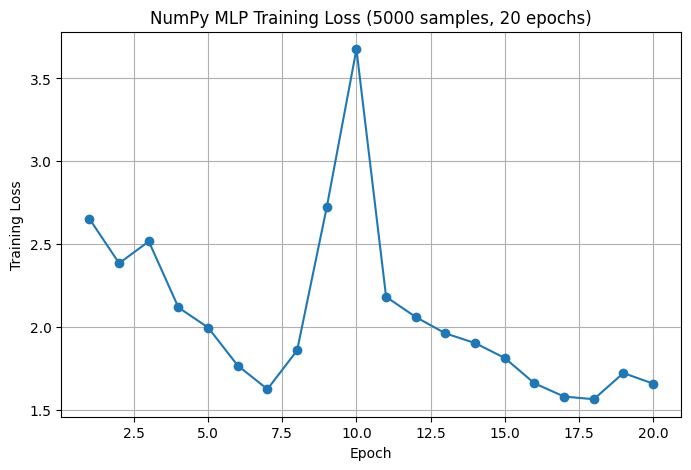

In [82]:

subset_size = 5000
X_sub = X_train[:subset_size]
y_sub = y_train[:subset_size]
Y_sub_onehot = one_hot(y_sub)

W1, b1, W2, b2 = init_params()

lr = 0.5
epochs = 20
losses = []

for epoch in range(epochs):
    A2, cache = forward(X_sub, W1, b1, W2, b2)
    loss = cross_entropy_loss(A2, Y_sub_onehot)
    losses.append(loss)

    grads = backward(cache, Y_sub_onehot, W1, W2)
    W1, b1, W2, b2 = update_params(W1, b1, W2, b2, grads, lr)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {loss:.4f}")

plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("NumPy MLP Training Loss (5000 samples, 20 epochs)")
plt.grid(True)
plt.show()

In [83]:
import torch
import torch.nn as nn
import torch.nn.functional as F


W1_np, b1_np, W2_np, b2_np = init_params(seed=42)

batch_size = 64
X_batch = X_sub[:batch_size]
y_batch = y_sub[:batch_size]
Y_batch_onehot = one_hot(y_batch)

A2_np, cache_np = forward(X_batch, W1_np, b1_np, W2_np, b2_np)
grads_np = backward(cache_np, Y_batch_onehot, W1_np, W2_np)

torch.manual_seed(42)  
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        z1 = self.fc1(x)
        a1 = F.relu(z1)
        z2 = self.fc2(a1)
        return z2  

model = MLP()

with torch.no_grad():
    model.fc1.weight.copy_(torch.tensor(W1_np.T, dtype=torch.float32))
    model.fc1.bias.copy_(torch.tensor(b1_np.flatten(), dtype=torch.float32))
    model.fc2.weight.copy_(torch.tensor(W2_np.T, dtype=torch.float32))
    model.fc2.bias.copy_(torch.tensor(b2_np.flatten(), dtype=torch.float32))

X_batch_torch = torch.tensor(X_batch, dtype=torch.float32)
y_batch_torch = torch.tensor(y_batch, dtype=torch.long)


logits = model(X_batch_torch)

loss_fn = nn.CrossEntropyLoss()
loss = loss_fn(logits, y_batch_torch)

model.zero_grad()
loss.backward()

print(f"PyTorch loss: {loss.item():.6f}")
print(f"NumPy loss:   {cross_entropy_loss(A2_np, Y_batch_onehot):.6f}")

PyTorch loss: 2.635332
NumPy loss:   2.635332


In [84]:

dW1_torch = model.fc1.weight.grad.numpy().T  
db1_torch = model.fc1.bias.grad.numpy().reshape(1, -1)
dW2_torch = model.fc2.weight.grad.numpy().T   
db2_torch = model.fc2.bias.grad.numpy().reshape(1, -1) 


max_diff_W1 = np.max(np.abs(grads_np['dW1'] - dW1_torch))
max_diff_b1 = np.max(np.abs(grads_np['db1'] - db1_torch))
max_diff_W2 = np.max(np.abs(grads_np['dW2'] - dW2_torch))
max_diff_b2 = np.max(np.abs(grads_np['db2'] - db2_torch))

print(f"Max abs diff dW1: {max_diff_W1:.2e}")
print(f"Max abs diff db1: {max_diff_b1:.2e}")
print(f"Max abs diff dW2: {max_diff_W2:.2e}")
print(f"Max abs diff db2: {max_diff_b2:.2e}")

Max abs diff dW1: 1.59e-08
Max abs diff db1: 7.86e-09
Max abs diff dW2: 3.24e-08
Max abs diff db2: 1.16e-08


**Part - 02**

In [85]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

class MLP2Layer(nn.Module):
    def __init__(self, activation='relu', hidden1=128, hidden2=64):
        super().__init__()
        self.fc1 = nn.Linear(784, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, 10)
        self.activation_name = activation

    def activate(self, x):
        if self.activation_name == 'sigmoid':
            return torch.sigmoid(x)
        elif self.activation_name == 'tanh':
            return torch.tanh(x)
        elif self.activation_name == 'relu':
            return F.relu(x)
        elif self.activation_name == 'leaky_relu':
            return F.leaky_relu(x, negative_slope=0.01)
        else:
            raise ValueError("Unknown activation")

    def forward(self, x):
        z1 = self.fc1(x)
        a1 = self.activate(z1)
        z2 = self.fc2(a1)
        a2 = self.activate(z2)
        z3 = self.fc3(a2)
        return z3, a1  

In [86]:
from torch.utils.data import TensorDataset, DataLoader

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t   = torch.tensor(X_val, dtype=torch.float32)
y_val_t   = torch.tensor(y_val, dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=128, shuffle=True)

val_dataset = TensorDataset(X_val_t, y_val_t)
val_loader  = DataLoader(val_dataset, batch_size=128, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


In [87]:
def train_model(activation, epochs=15, lr=0.01, seed=42):
    torch.manual_seed(seed)
    model = MLP2Layer(activation=activation).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    val_losses = []
    grad_records = {} 

    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits, _ = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()

           
            if epoch == 1 or epoch == epochs:
                mean_abs_grad = model.fc1.weight.grad.abs().mean().item()
                grad_records[epoch] = mean_abs_grad  # overwritten each batch; last batch's value kept

            optimizer.step()

        model.eval()
        val_loss_total = 0.0
        n_batches = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits, _ = model(xb)
                loss = loss_fn(logits, yb)
                val_loss_total += loss.item()
                n_batches += 1
        val_loss_avg = val_loss_total / n_batches
        val_losses.append(val_loss_avg)
        print(f"[{activation}] Epoch {epoch}/{epochs} - Val Loss: {val_loss_avg:.4f}")
    return model, val_losses, grad_records

In [88]:
activations = ['sigmoid', 'tanh', 'relu', 'leaky_relu']
results = {}

for act in activations:
    model, val_losses, grad_records = train_model(act, epochs=15, lr=0.01)
    results[act] = {'model': model, 'val_losses': val_losses, 'grad_records': grad_records}

[sigmoid] Epoch 1/15 - Val Loss: 2.2985
[sigmoid] Epoch 2/15 - Val Loss: 2.2930
[sigmoid] Epoch 3/15 - Val Loss: 2.2860
[sigmoid] Epoch 4/15 - Val Loss: 2.2766
[sigmoid] Epoch 5/15 - Val Loss: 2.2619
[sigmoid] Epoch 6/15 - Val Loss: 2.2382
[sigmoid] Epoch 7/15 - Val Loss: 2.1970
[sigmoid] Epoch 8/15 - Val Loss: 2.1228
[sigmoid] Epoch 9/15 - Val Loss: 2.0024
[sigmoid] Epoch 10/15 - Val Loss: 1.8588
[sigmoid] Epoch 11/15 - Val Loss: 1.7342
[sigmoid] Epoch 12/15 - Val Loss: 1.6340
[sigmoid] Epoch 13/15 - Val Loss: 1.5463
[sigmoid] Epoch 14/15 - Val Loss: 1.4668
[sigmoid] Epoch 15/15 - Val Loss: 1.3968
[tanh] Epoch 1/15 - Val Loss: 1.2728
[tanh] Epoch 2/15 - Val Loss: 0.9162
[tanh] Epoch 3/15 - Val Loss: 0.7731
[tanh] Epoch 4/15 - Val Loss: 0.6938
[tanh] Epoch 5/15 - Val Loss: 0.6391
[tanh] Epoch 6/15 - Val Loss: 0.6011
[tanh] Epoch 7/15 - Val Loss: 0.5687
[tanh] Epoch 8/15 - Val Loss: 0.5443
[tanh] Epoch 9/15 - Val Loss: 0.5243
[tanh] Epoch 10/15 - Val Loss: 0.5085
[tanh] Epoch 11/15 - Va

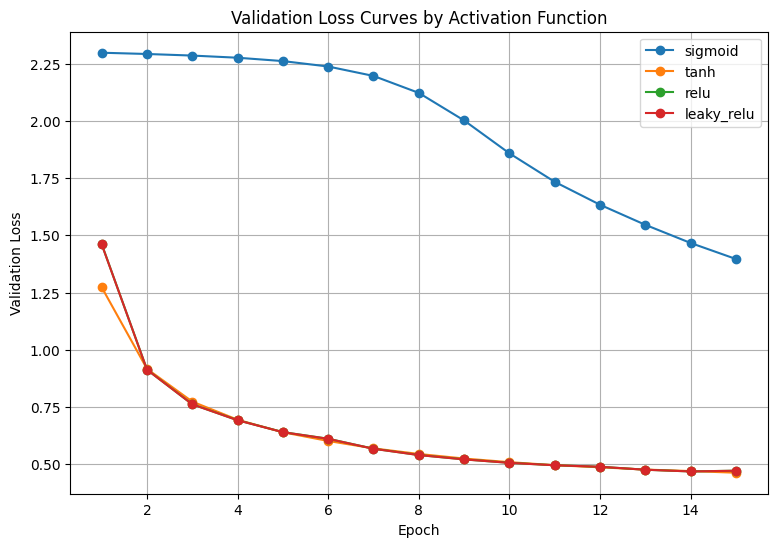

In [89]:
plt.figure(figsize=(9,6))
for act in activations:
    plt.plot(range(1, len(results[act]['val_losses'])+1), results[act]['val_losses'], label=act, marker='o')

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Curves by Activation Function")
plt.legend()
plt.grid(True)
plt.show()

In [90]:
print("=== Mean Absolute Gradient of First Hidden Layer (fc1) ===\n")

for act in ['sigmoid', 'relu']:
    grad_records = results[act]['grad_records']
    epoch1_grad = grad_records[1]
    final_epoch = max(grad_records.keys())
    final_grad = grad_records[final_epoch]

    print(f"[{act}]")
    print(f"  Epoch 1 mean |grad|:          {epoch1_grad:.8f}")
    print(f"  Final epoch ({final_epoch}) mean |grad|: {final_grad:.8f}")
    print(f"  Ratio (final / epoch1):       {final_grad/epoch1_grad:.4f}\n")

=== Mean Absolute Gradient of First Hidden Layer (fc1) ===

[sigmoid]
  Epoch 1 mean |grad|:          0.00009311
  Final epoch (15) mean |grad|: 0.00020813
  Ratio (final / epoch1):       2.2354

[relu]
  Epoch 1 mean |grad|:          0.00089007
  Final epoch (15) mean |grad|: 0.00254364
  Ratio (final / epoch1):       2.8578



In [91]:
relu_model = results['relu']['model']
relu_model.eval()

# Grab one validation batch
xb, yb = next(iter(val_loader))
xb = xb.to(device)

with torch.no_grad():
    _, a1 = relu_model(xb) 
dead_units_mask = (a1 == 0).all(dim=0)  # shape (hidden1,) -> True where unit is dead across all samples
num_dead = dead_units_mask.sum().item()
total_units = a1.shape[1]
pct_dead = (num_dead / total_units) * 100

print(f"Total hidden units in first layer: {total_units}")
print(f"Dead units (output 0 for every sample in this batch): {num_dead}")
print(f"Percentage of dead units: {pct_dead:.2f}%")

Total hidden units in first layer: 128
Dead units (output 0 for every sample in this batch): 3
Percentage of dead units: 2.34%


**Part -03**

In [92]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

class ClassifierMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [93]:
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

# one-hot targets needed only for the mse version
def one_hot_torch(y, num_classes=10):
    return torch.eye(num_classes)[y]

y_train_onehot = one_hot_torch(y_train_t)
y_test_onehot  = one_hot_torch(y_test_t)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t, y_train_onehot), batch_size=128, shuffle=True)

In [94]:
def train_classifier(loss_type='ce', epochs=15, lr=0.01, seed=42):
    torch.manual_seed(seed)
    model = ClassifierMLP().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    train_losses = []

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        n_batches = 0

        for xb, yb, yb_onehot in train_loader:
            xb, yb, yb_onehot = xb.to(device), yb.to(device), yb_onehot.to(device)
            optimizer.zero_grad()
            logits = model(xb)

            if loss_type == 'ce':
    
                loss = F.cross_entropy(logits, yb)
            else:
                
                probs = F.softmax(logits, dim=1)
                loss = F.mse_loss(probs, yb_onehot)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        avg_loss = epoch_loss / n_batches
        train_losses.append(avg_loss)
        print(f"[{loss_type}] epoch {epoch}/{epochs} - loss: {avg_loss:.4f}")

    return model, train_losses

In [95]:
def test_accuracy(model, X_test_t, y_test_t):
    model.eval()
    with torch.no_grad():
        logits = model(X_test_t.to(device))
        preds = logits.argmax(dim=1).cpu()
        acc = (preds == y_test_t).float().mean().item()
    return acc

model_ce, losses_ce = train_classifier(loss_type='ce', epochs=15, lr=0.01)
acc_ce = test_accuracy(model_ce, X_test_t, y_test_t)

model_mse, losses_mse = train_classifier(loss_type='mse', epochs=15, lr=0.01)
acc_mse = test_accuracy(model_mse, X_test_t, y_test_t)

print(f"\ntest accuracy with cross entropy: {acc_ce*100:.2f}%")
print(f"test accuracy with mse: {acc_mse*100:.2f}%")

[ce] epoch 1/15 - loss: 1.9878
[ce] epoch 2/15 - loss: 1.1284
[ce] epoch 3/15 - loss: 0.8308
[ce] epoch 4/15 - loss: 0.7276
[ce] epoch 5/15 - loss: 0.6657
[ce] epoch 6/15 - loss: 0.6198
[ce] epoch 7/15 - loss: 0.5841
[ce] epoch 8/15 - loss: 0.5566
[ce] epoch 9/15 - loss: 0.5357
[ce] epoch 10/15 - loss: 0.5194
[ce] epoch 11/15 - loss: 0.5060
[ce] epoch 12/15 - loss: 0.4960
[ce] epoch 13/15 - loss: 0.4858
[ce] epoch 14/15 - loss: 0.4770
[ce] epoch 15/15 - loss: 0.4701
[mse] epoch 1/15 - loss: 0.0901
[mse] epoch 2/15 - loss: 0.0899
[mse] epoch 3/15 - loss: 0.0898
[mse] epoch 4/15 - loss: 0.0896
[mse] epoch 5/15 - loss: 0.0895
[mse] epoch 6/15 - loss: 0.0894
[mse] epoch 7/15 - loss: 0.0892
[mse] epoch 8/15 - loss: 0.0891
[mse] epoch 9/15 - loss: 0.0889
[mse] epoch 10/15 - loss: 0.0888
[mse] epoch 11/15 - loss: 0.0886
[mse] epoch 12/15 - loss: 0.0884
[mse] epoch 13/15 - loss: 0.0882
[mse] epoch 14/15 - loss: 0.0880
[mse] epoch 15/15 - loss: 0.0877

test accuracy with cross entropy: 83.35%
t

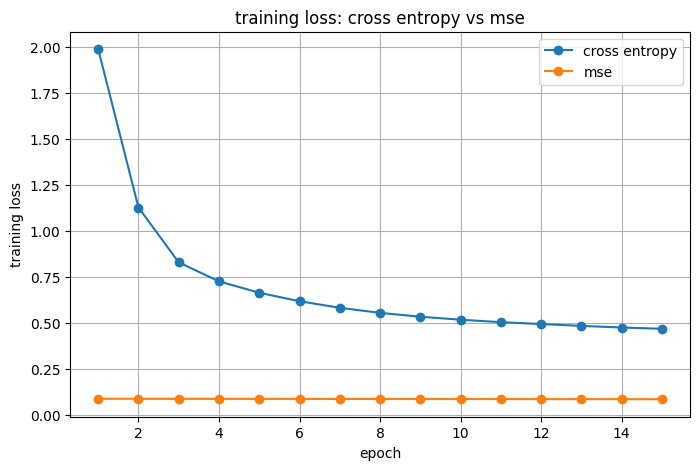

In [96]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(losses_ce)+1), losses_ce, label='cross entropy', marker='o')
plt.plot(range(1, len(losses_mse)+1), losses_mse, label='mse', marker='o')
plt.xlabel('epoch')
plt.ylabel('training loss')
plt.title('training loss: cross entropy vs mse')
plt.legend()
plt.grid(True)
plt.show()

Cross entropy converges faster because its gradient is directly proportional to the difference between the predicted probability and the true label, so wrong predictions get a strong, direct push to correct themselves. mse instead multiplies that error by the derivative of the softmax function, which becomes very small once a prediction is confidently wrong or confidently right, so the gradient shrinks and learning slows down a lot, which matches the almost flat mse curve we saw.

In [97]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split as tts
from sklearn.preprocessing import StandardScaler

# load dataset
housing = fetch_california_housing()
X_reg = housing.data
y_reg = housing.target

print("features shape:", X_reg.shape)
print("target shape:", y_reg.shape)
print("feature names:", housing.feature_names)

features shape: (20640, 8)
target shape: (20640,)
feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [98]:

X_reg_train, X_reg_test, y_reg_train, y_reg_test = tts(X_reg, y_reg, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_reg_train_scaled = scaler.fit_transform(X_reg_train)
X_reg_test_scaled = scaler.transform(X_reg_test)

X_reg_train_t = torch.tensor(X_reg_train_scaled, dtype=torch.float32)
y_reg_train_t = torch.tensor(y_reg_train, dtype=torch.float32).view(-1, 1)
X_reg_test_t = torch.tensor(X_reg_test_scaled, dtype=torch.float32)
y_reg_test_t = torch.tensor(y_reg_test, dtype=torch.float32).view(-1, 1)

print("train size:", X_reg_train_t.shape)
print("test size:", X_reg_test_t.shape)

train size: torch.Size([16512, 8])
test size: torch.Size([4128, 8])


In [99]:
class RegressionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(8, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

torch.manual_seed(42)
reg_model = RegressionMLP().to(device)
optimizer = torch.optim.Adam(reg_model.parameters(), lr=0.01)

epochs = 50
X_reg_train_t = X_reg_train_t.to(device)
y_reg_train_t = y_reg_train_t.to(device)

for epoch in range(1, epochs + 1):
    reg_model.train()
    optimizer.zero_grad()
    preds = reg_model(X_reg_train_t)
    loss = F.mse_loss(preds, y_reg_train_t)
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"epoch {epoch}/{epochs} - train mse: {loss.item():.4f}")

epoch 10/50 - train mse: 1.7470
epoch 20/50 - train mse: 0.9050
epoch 30/50 - train mse: 0.7701
epoch 40/50 - train mse: 0.6545
epoch 50/50 - train mse: 0.5665


In [100]:
reg_model.eval()
with torch.no_grad():
    test_preds = reg_model(X_reg_test_t.to(device)).cpu()

mse = F.mse_loss(test_preds, y_reg_test_t).item()
rmse = mse ** 0.5
mae = F.l1_loss(test_preds, y_reg_test_t).item()

print(f"test mse: {mse:.4f}")
print(f"test rmse: {rmse:.4f}")
print(f"test mae: {mae:.4f}")

test mse: 0.5885
test rmse: 0.7671
test mae: 0.5407


**Part - 04**

In [101]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class OptimMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

def get_optimizer(name, model, lr):
    if name == 'sgd':
        return torch.optim.SGD(model.parameters(), lr=lr)
    elif name == 'sgd_momentum':
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif name == 'rmsprop':
        return torch.optim.RMSprop(model.parameters(), lr=lr)
    elif name == 'adam':
        return torch.optim.Adam(model.parameters(), lr=lr)
    else:
        raise ValueError("unknown optimizer name")

In [102]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t   = torch.tensor(X_val, dtype=torch.float32)
y_val_t   = torch.tensor(y_val, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=128, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=128, shuffle=False)

In [103]:
def train_with_optimizer(opt_name, lr, epochs=20, seed=42, target_acc=0.85):
    torch.manual_seed(seed)
    model = OptimMLP().to(device)
    optimizer = get_optimizer(opt_name, model, lr)

    train_losses = []
    val_accs = []
    epochs_to_target = None 
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        train_losses.append(epoch_loss / n_batches)
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb).argmax(dim=1)
                correct += (preds == yb).sum().item()
                total += yb.size(0)
        val_acc = correct / total
        val_accs.append(val_acc)

        if epochs_to_target is None and val_acc >= target_acc:
            epochs_to_target = epoch

        print(f"[{opt_name}, lr={lr}] epoch {epoch}/{epochs} - train loss: {train_losses[-1]:.4f} - val acc: {val_acc:.4f}")

    wall_time = time.time() - start_time

    return {
        'train_losses': train_losses,
        'val_accs': val_accs,
        'epochs_to_target': epochs_to_target,
        'final_val_acc': val_accs[-1],
        'wall_time': wall_time
    }

In [104]:
same_lr = 0.01
optimizers_list = ['sgd', 'sgd_momentum', 'rmsprop', 'adam']

results_same_lr = {}
for opt_name in optimizers_list:
    print(f"\n--- training with {opt_name}, lr={same_lr} ---")
    results_same_lr[opt_name] = train_with_optimizer(opt_name, lr=same_lr, epochs=20)


--- training with sgd, lr=0.01 ---
[sgd, lr=0.01] epoch 1/20 - train loss: 1.9878 - val acc: 0.5577
[sgd, lr=0.01] epoch 2/20 - train loss: 1.1271 - val acc: 0.6709
[sgd, lr=0.01] epoch 3/20 - train loss: 0.8305 - val acc: 0.7184
[sgd, lr=0.01] epoch 4/20 - train loss: 0.7277 - val acc: 0.7541
[sgd, lr=0.01] epoch 5/20 - train loss: 0.6656 - val acc: 0.7774
[sgd, lr=0.01] epoch 6/20 - train loss: 0.6193 - val acc: 0.7870
[sgd, lr=0.01] epoch 7/20 - train loss: 0.5838 - val acc: 0.8017
[sgd, lr=0.01] epoch 8/20 - train loss: 0.5572 - val acc: 0.8128
[sgd, lr=0.01] epoch 9/20 - train loss: 0.5359 - val acc: 0.8159
[sgd, lr=0.01] epoch 10/20 - train loss: 0.5191 - val acc: 0.8222
[sgd, lr=0.01] epoch 11/20 - train loss: 0.5060 - val acc: 0.8239
[sgd, lr=0.01] epoch 12/20 - train loss: 0.4971 - val acc: 0.8251
[sgd, lr=0.01] epoch 13/20 - train loss: 0.4859 - val acc: 0.8324
[sgd, lr=0.01] epoch 14/20 - train loss: 0.4778 - val acc: 0.8352
[sgd, lr=0.01] epoch 15/20 - train loss: 0.4703 -

In [105]:
for opt_name in optimizers_list:
    wt = results_same_lr[opt_name]['wall_time']
    print(f"{opt_name}: {wt:.2f} seconds")

sgd: 18.70 seconds
sgd_momentum: 19.29 seconds
rmsprop: 20.78 seconds
adam: 21.61 seconds


In [106]:
tuned_lrs = {
    'sgd': 0.1,          
    'sgd_momentum': 0.05, 
    'rmsprop': 0.001,     
    'adam': 0.001 }        

results_tuned_lr = {}
for opt_name in optimizers_list:
    lr = tuned_lrs[opt_name]
    print(f"\n--- training with {opt_name}, lr={lr} (tuned) ---")
    results_tuned_lr[opt_name] = train_with_optimizer(opt_name, lr=lr, epochs=20)


--- training with sgd, lr=0.1 (tuned) ---
[sgd, lr=0.1] epoch 1/20 - train loss: 0.8999 - val acc: 0.7668
[sgd, lr=0.1] epoch 2/20 - train loss: 0.5282 - val acc: 0.8030
[sgd, lr=0.1] epoch 3/20 - train loss: 0.4666 - val acc: 0.8430
[sgd, lr=0.1] epoch 4/20 - train loss: 0.4296 - val acc: 0.8417
[sgd, lr=0.1] epoch 5/20 - train loss: 0.4028 - val acc: 0.8412
[sgd, lr=0.1] epoch 6/20 - train loss: 0.3839 - val acc: 0.8600
[sgd, lr=0.1] epoch 7/20 - train loss: 0.3680 - val acc: 0.8621
[sgd, lr=0.1] epoch 8/20 - train loss: 0.3569 - val acc: 0.8663
[sgd, lr=0.1] epoch 9/20 - train loss: 0.3424 - val acc: 0.8714
[sgd, lr=0.1] epoch 10/20 - train loss: 0.3315 - val acc: 0.8700
[sgd, lr=0.1] epoch 11/20 - train loss: 0.3230 - val acc: 0.8678
[sgd, lr=0.1] epoch 12/20 - train loss: 0.3169 - val acc: 0.8785
[sgd, lr=0.1] epoch 13/20 - train loss: 0.3068 - val acc: 0.8765
[sgd, lr=0.1] epoch 14/20 - train loss: 0.3014 - val acc: 0.8832
[sgd, lr=0.1] epoch 15/20 - train loss: 0.2929 - val acc

In [107]:
for opt_name in optimizers_list:
    wt = results_tuned_lr[opt_name]['wall_time']
    print(f"{opt_name}: {wt:.2f} seconds")

sgd: 18.87 seconds
sgd_momentum: 19.00 seconds
rmsprop: 20.64 seconds
adam: 21.15 seconds


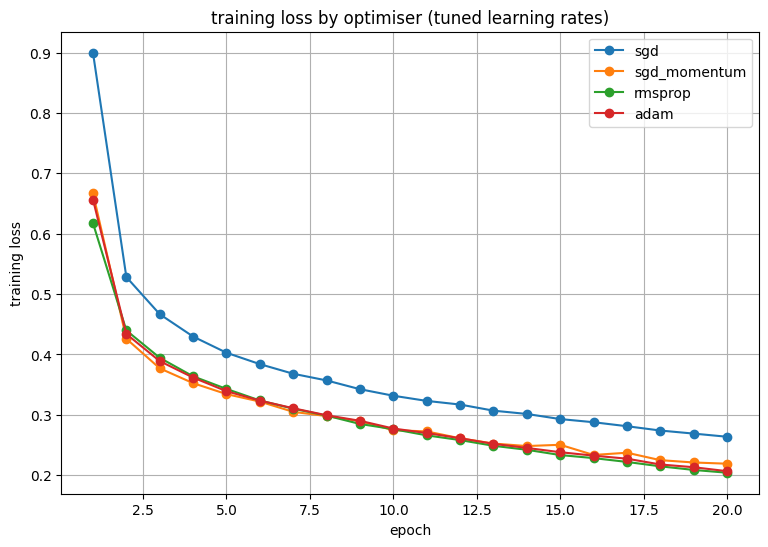

In [108]:
plt.figure(figsize=(9,6))
for opt_name in optimizers_list:
    losses = results_tuned_lr[opt_name]['train_losses']
    plt.plot(range(1, len(losses)+1), losses, label=opt_name, marker='o')

plt.xlabel('epoch')
plt.ylabel('training loss')
plt.title('training loss by optimiser (tuned learning rates)')
plt.legend()
plt.grid(True)
plt.show()

| Optimiser        | Learning rate | Epochs to reach 85% val acc | Final val acc | Wall-clock time |
|------------------|---------------|------------------------------|----------------|------------------|
| SGD              | 0.01 (same)   | not reached                 | 0.8443         | 19.86s           |
| SGD + momentum   | 0.01 (same)   | 9                            | 0.8842         | 19.81s           |
| RMSProp          | 0.01 (same)   | 7                            | 0.8678         | 21.30s           |
| Adam             | 0.01 (same)   | 2                            | 0.8763         | 22.09s           |
| SGD              | 0.1 (tuned)   | 6                            | 0.8879         | 19.07s           |
| SGD + momentum   | 0.05 (tuned)  | 2                            | 0.8877         | 19.47s           |
| RMSProp          | 0.001 (tuned) | 3                            | 0.8890         | 21.03s           |
| Adam             | 0.001 (tuned) | 2                            | 0.8911         | 21.25s           |

adam is the optimiser to choose, since it reached 85% validation accuracy fastest in both experiments (2 epochs) and produced the highest final accuracy overall (0.8911) with minimal learning rate tuning needed. the extra wall-clock cost compared to plain sgd is small (about 2 seconds over 20 epochs), so the faster convergence and better final accuracy easily outweigh that minor overhead.

**Part - 05**

In [109]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# reduce training set to 2000 samples
subset_size = 2000
X_overfit = X_train[:subset_size]
y_overfit = y_train[:subset_size]

X_overfit_t = torch.tensor(X_overfit, dtype=torch.float32)
y_overfit_t = torch.tensor(y_overfit, dtype=torch.long)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_overfit_t, y_overfit_t), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64, shuffle=False)

print("training samples:", X_overfit.shape[0])

training samples: 2000


In [110]:
class BigMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 512)
        self.fc4 = nn.Linear(512, 512)
        self.fc5 = nn.Linear(512, 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = self.fc5(x)
        return x

torch.manual_seed(42)
model = BigMLP().to(device)
print(model)

BigMLP(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=512, bias=True)
  (fc4): Linear(in_features=512, out_features=512, bias=True)
  (fc5): Linear(in_features=512, out_features=10, bias=True)
)


In [111]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 60  # generous, since we need train acc > 99%

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    train_loss = total_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # validation
    model.eval()
    val_total_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            val_total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            val_correct += (preds == yb).sum().item()
            val_total += yb.size(0)

    val_loss = val_total_loss / val_total
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"epoch {epoch}/{epochs} - train loss: {train_loss:.4f} - train acc: {train_acc:.4f} - val loss: {val_loss:.4f} - val acc: {val_acc:.4f}")

    # stop early once training accuracy clearly exceeds 99% and we've run a good number of epochs
    if train_acc > 0.99 and epoch >= 20:
        print(f"\ntraining accuracy exceeded 99% at epoch {epoch}, stopping")
        break

epoch 1/60 - train loss: 1.4990 - train acc: 0.4250 - val loss: 0.9659 - val acc: 0.6011
epoch 2/60 - train loss: 0.8462 - train acc: 0.6640 - val loss: 0.7231 - val acc: 0.7150
epoch 3/60 - train loss: 0.6947 - train acc: 0.7445 - val loss: 0.7193 - val acc: 0.7254
epoch 4/60 - train loss: 0.6286 - train acc: 0.7570 - val loss: 0.6487 - val acc: 0.7563
epoch 5/60 - train loss: 0.5320 - train acc: 0.8070 - val loss: 0.5799 - val acc: 0.7768
epoch 6/60 - train loss: 0.4743 - train acc: 0.8300 - val loss: 0.5621 - val acc: 0.7925
epoch 7/60 - train loss: 0.4353 - train acc: 0.8370 - val loss: 0.5822 - val acc: 0.7885
epoch 8/60 - train loss: 0.3881 - train acc: 0.8530 - val loss: 0.5509 - val acc: 0.8107
epoch 9/60 - train loss: 0.3894 - train acc: 0.8560 - val loss: 0.6113 - val acc: 0.7859
epoch 10/60 - train loss: 0.3964 - train acc: 0.8500 - val loss: 0.5928 - val acc: 0.7858
epoch 11/60 - train loss: 0.3516 - train acc: 0.8650 - val loss: 0.6820 - val acc: 0.7678
epoch 12/60 - train

In [112]:
extra_epochs = 20

for i in range(extra_epochs):
    epoch = len(train_losses) + 1

    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    train_loss = total_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    model.eval()
    val_total_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            val_total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            val_correct += (preds == yb).sum().item()
            val_total += yb.size(0)

    val_loss = val_total_loss / val_total
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"epoch {epoch} - train loss: {train_loss:.4f} - train acc: {train_acc:.4f} - val loss: {val_loss:.4f} - val acc: {val_acc:.4f}")

    if train_acc > 0.99:
        print(f"\ntraining accuracy exceeded 99% at epoch {epoch}, stopping")
        break

epoch 61 - train loss: 0.0926 - train acc: 0.9725 - val loss: 1.1008 - val acc: 0.8286
epoch 62 - train loss: 0.0312 - train acc: 0.9900 - val loss: 1.1873 - val acc: 0.8247
epoch 63 - train loss: 0.0445 - train acc: 0.9845 - val loss: 1.0717 - val acc: 0.8297
epoch 64 - train loss: 0.0187 - train acc: 0.9935 - val loss: 1.3080 - val acc: 0.8212

training accuracy exceeded 99% at epoch 64, stopping


validation loss reaches its minimum at epoch 8 (val loss = 0.5509)
after this point, validation loss trends upward while training loss keeps falling -- this is where the curves separate


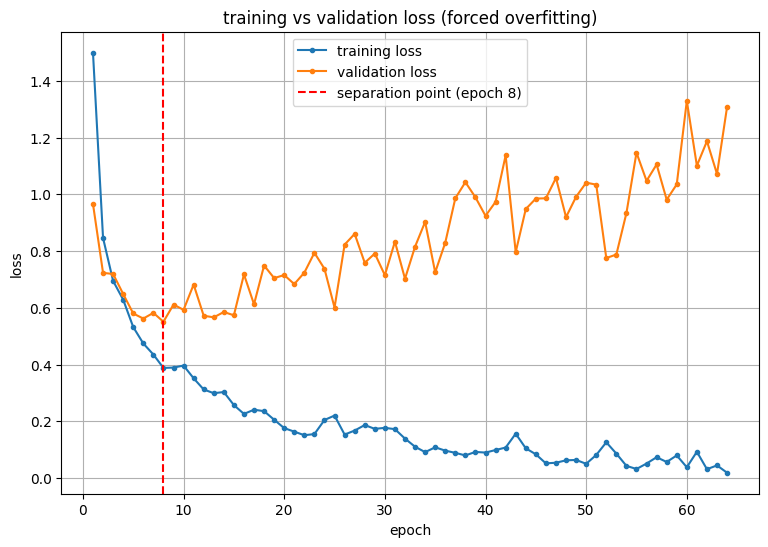

In [113]:

val_losses_arr = np.array(val_losses)
train_losses_arr = np.array(train_losses)

min_val_loss_epoch = np.argmin(val_losses_arr) + 1  
print(f"validation loss reaches its minimum at epoch {min_val_loss_epoch} (val loss = {val_losses_arr[min_val_loss_epoch-1]:.4f})")
print(f"after this point, validation loss trends upward while training loss keeps falling -- this is where the curves separate")

plt.figure(figsize=(9,6))
epochs_range = range(1, len(train_losses)+1)
plt.plot(epochs_range, train_losses, label='training loss', marker='o', markersize=3)
plt.plot(epochs_range, val_losses, label='validation loss', marker='o', markersize=3)
plt.axvline(x=min_val_loss_epoch, color='red', linestyle='--', label=f'separation point (epoch {min_val_loss_epoch})')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('training vs validation loss (forced overfitting)')
plt.legend()
plt.grid(True)
plt.show()

In [114]:
final_train_acc = train_accs[-1]
final_val_acc = val_accs[-1]
gap = final_train_acc - final_val_acc

print(f"final training accuracy: {final_train_acc*100:.2f}%")
print(f"final validation accuracy: {final_val_acc*100:.2f}%")
print(f"generalisation gap: {gap*100:.2f} percentage points")

final training accuracy: 99.35%
final validation accuracy: 82.12%
generalisation gap: 17.23 percentage points


This model has high variance, not high bias. Training accuracy of 99.35% shows it can fit the training data almost perfectly, so it's not underfitting — that rules out high bias. The 17.23 point gap between train and validation accuracy, plus validation loss climbing while training loss keeps falling, shows the model is just memorising the small training set instead of learning patterns that generalise.

**Part - 06**

In [115]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader, Dataset
from torchvision import transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class RegMLP(nn.Module):
    def __init__(self, dropout_rate=0.0, use_batchnorm=False):
        super().__init__()
        self.use_batchnorm = use_batchnorm
        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 512)
        self.fc4 = nn.Linear(512, 512)
        self.fc5 = nn.Linear(512, 10)

        if use_batchnorm:
            self.bn1 = nn.BatchNorm1d(512)
            self.bn2 = nn.BatchNorm1d(512)
            self.bn3 = nn.BatchNorm1d(512)
            self.bn4 = nn.BatchNorm1d(512)

        self.dropout = nn.Dropout(dropout_rate) if dropout_rate > 0 else None

    def forward(self, x):
        x = self.fc1(x)
        if self.use_batchnorm: x = self.bn1(x)
        x = F.relu(x)
        if self.dropout: x = self.dropout(x)

        x = self.fc2(x)
        if self.use_batchnorm: x = self.bn2(x)
        x = F.relu(x)
        if self.dropout: x = self.dropout(x)

        x = self.fc3(x)
        if self.use_batchnorm: x = self.bn3(x)
        x = F.relu(x)
        if self.dropout: x = self.dropout(x)

        x = self.fc4(x)
        if self.use_batchnorm: x = self.bn4(x)
        x = F.relu(x)
        if self.dropout: x = self.dropout(x)

        x = self.fc5(x)
        return x

In [116]:
class FashionDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = X
        self.y = y
        self.augment = augment
        self.transform = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(10),
        ])

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx].reshape(28, 28)
        img_t = torch.tensor(img, dtype=torch.float32).unsqueeze(0)  # 1x28x28
        if self.augment:
            img_t = self.transform(img_t)
        img_flat = img_t.flatten()
        label = self.y[idx]
        return img_flat, label

In [117]:
def train_regularized(train_size=2000, epochs=60, lr=0.001,
                       weight_decay=0.0, l1_lambda=0.0,
                       dropout_rate=0.0, use_batchnorm=False,
                       augmentation=False, early_stopping_patience=None,
                       seed=42):
    torch.manual_seed(seed)

    X_sub = X_train[:train_size]
    y_sub = y_train[:train_size]

    train_ds = FashionDataset(X_sub, y_sub, augment=augmentation)
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

    val_ds = FashionDataset(X_val, y_val, augment=False)
    val_loader_local = DataLoader(val_ds, batch_size=64, shuffle=False)

    model = RegMLP(dropout_rate=dropout_rate, use_batchnorm=use_batchnorm).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_loss = float('inf')
    patience_counter = 0
    stopped_epoch = epochs

    train_accs, val_accs = [], []
    train_losses_log, val_losses_log = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        correct, total, total_loss = 0, 0, 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)

            if l1_lambda > 0:
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                loss = loss + l1_lambda * l1_norm

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            correct += (logits.argmax(1) == yb).sum().item()
            total += yb.size(0)

        train_acc = correct / total
        train_loss = total_loss / total

        model.eval()
        vcorrect, vtotal, vtotal_loss = 0, 0, 0.0
        with torch.no_grad():
            for xb, yb in val_loader_local:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = F.cross_entropy(logits, yb)
                vtotal_loss += loss.item() * xb.size(0)
                vcorrect += (logits.argmax(1) == yb).sum().item()
                vtotal += yb.size(0)
        val_acc = vcorrect / vtotal
        val_loss = vtotal_loss / vtotal

        train_accs.append(train_acc); val_accs.append(val_acc)
        train_losses_log.append(train_loss); val_losses_log.append(val_loss)

        if early_stopping_patience is not None:
            if val_loss < best_val_loss - 1e-4:
                best_val_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= early_stopping_patience:
                    stopped_epoch = epoch
                    break

    final_train_acc = train_accs[-1]
    final_val_acc = val_accs[-1]
    gap = final_train_acc - final_val_acc

    pct_small_weights = None
    if l1_lambda > 0:
        all_weights = torch.cat([p.flatten() for name, p in model.named_parameters() if 'weight' in name])
        pct_small_weights = (all_weights.abs() < 1e-3).float().mean().item() * 100

    return {
        'train_acc': final_train_acc, 'val_acc': final_val_acc, 'gap': gap,
        'train_accs': train_accs, 'val_accs': val_accs,
        'train_losses': train_losses_log, 'val_losses': val_losses_log,
        'stopped_epoch': stopped_epoch, 'pct_small_weights': pct_small_weights
    }

In [118]:
baseline_result = {
    'train_acc': 0.9935,
    'val_acc': 0.8212,
    'gap': 0.9935 - 0.8212
}
print(f"baseline - train acc: {baseline_result['train_acc']*100:.2f}%, val acc: {baseline_result['val_acc']*100:.2f}%, gap: {baseline_result['gap']*100:.2f} pts")

baseline - train acc: 99.35%, val acc: 82.12%, gap: 17.23 pts


In [119]:
l2_lambdas = [1e-4, 1e-3, 1e-2]
l2_results = {}

for lam in l2_lambdas:
    print(f"\n--- training with l2 weight_decay={lam} ---")
    result = train_regularized(train_size=2000, epochs=60, weight_decay=lam)
    l2_results[lam] = result
    print(f"lambda={lam} - train acc: {result['train_acc']*100:.2f}% - val acc: {result['val_acc']*100:.2f}% - gap: {result['gap']*100:.2f} pts")


--- training with l2 weight_decay=0.0001 ---
lambda=0.0001 - train acc: 98.60% - val acc: 81.77% - gap: 16.83 pts

--- training with l2 weight_decay=0.001 ---
lambda=0.001 - train acc: 96.20% - val acc: 81.47% - gap: 14.73 pts

--- training with l2 weight_decay=0.01 ---
lambda=0.01 - train acc: 90.45% - val acc: 80.88% - gap: 9.57 pts


In [120]:
print("--- training with l1 penalty ---")
l1_result = train_regularized(train_size=2000, epochs=60, l1_lambda=1e-5)
print(f"train acc: {l1_result['train_acc']*100:.2f}% - val acc: {l1_result['val_acc']*100:.2f}% - gap: {l1_result['gap']*100:.2f} pts")
print(f"percentage of weights below 1e-3: {l1_result['pct_small_weights']:.2f}%")

--- training with l1 penalty ---
train acc: 97.80% - val acc: 82.19% - gap: 15.61 pts
percentage of weights below 1e-3: 55.45%


In [121]:
dropout_rates = [0.2, 0.5, 0.7]
dropout_results = {}

for rate in dropout_rates:
    print(f"\n--- training with dropout_rate={rate} ---")
    result = train_regularized(train_size=2000, epochs=60, dropout_rate=rate)
    dropout_results[rate] = result
    print(f"dropout={rate} - train acc: {result['train_acc']*100:.2f}% - val acc: {result['val_acc']*100:.2f}% - gap: {result['gap']*100:.2f} pts")
    


--- training with dropout_rate=0.2 ---
dropout=0.2 - train acc: 95.75% - val acc: 82.60% - gap: 13.15 pts

--- training with dropout_rate=0.5 ---
dropout=0.5 - train acc: 87.75% - val acc: 83.15% - gap: 4.60 pts

--- training with dropout_rate=0.7 ---
dropout=0.7 - train acc: 78.35% - val acc: 79.59% - gap: -1.24 pts


In [122]:
print("--- training with batch normalisation ---")
bn_result = train_regularized(train_size=2000, epochs=60, use_batchnorm=True)
print(f"train acc: {bn_result['train_acc']*100:.2f}% - val acc: {bn_result['val_acc']*100:.2f}% - gap: {bn_result['gap']*100:.2f} pts")

--- training with batch normalisation ---
train acc: 98.40% - val acc: 81.62% - gap: 16.77 pts


In [123]:
patience = 5
print(f"--- training with early stopping (patience={patience}) ---")
es_result = train_regularized(train_size=2000, epochs=60, early_stopping_patience=patience)
print(f"train acc: {es_result['train_acc']*100:.2f}% - val acc: {es_result['val_acc']*100:.2f}% - gap: {es_result['gap']*100:.2f} pts")
print(f"training stopped at epoch: {es_result['stopped_epoch']}")

--- training with early stopping (patience=5) ---
train acc: 88.35% - val acc: 82.09% - gap: 6.26 pts
training stopped at epoch: 13


In [124]:
print("--- training with data augmentation ---")
aug_result = train_regularized(train_size=2000, epochs=60, augmentation=True)
print(f"train acc: {aug_result['train_acc']*100:.2f}% - val acc: {aug_result['val_acc']*100:.2f}% - gap: {aug_result['gap']*100:.2f} pts")

--- training with data augmentation ---
train acc: 91.75% - val acc: 82.06% - gap: 9.69 pts


In [125]:
data_sizes = [10000, 20000]
data_size_results = {}

for size in data_sizes:
    print(f"\n--- training with {size} samples ---")
    result = train_regularized(train_size=size, epochs=60)
    data_size_results[size] = result
    print(f"train_size={size} - train acc: {result['train_acc']*100:.2f}% - val acc: {result['val_acc']*100:.2f}% - gap: {result['gap']*100:.2f} pts")


--- training with 10000 samples ---
train_size=10000 - train acc: 97.46% - val acc: 86.75% - gap: 10.71 pts

--- training with 20000 samples ---
train_size=20000 - train acc: 97.95% - val acc: 87.63% - gap: 10.31 pts


| Method                        | Setting                          | Train accuracy | Validation accuracy | Gap    |
|-------------------------------|-----------------------------------|-----------------|----------------------|--------|
| Baseline (no regularisation)  | —                                 | 99.35%          | 82.12%               | 17.23  |
| L2 weight decay               | λ=0.0001                          | 98.60%          | 81.77%               | 16.83  |
| L2 weight decay               | λ=0.001                           | 96.20%          | 81.47%               | 14.73  |
| L2 weight decay               | λ=0.01                            | 90.45%          | 80.88%               | 9.57   |
| L1 penalty                    | λ=1e-5 (55.45% weights < 1e-3)    | 97.80%          | 82.19%               | 15.61  |
| Dropout                       | rate=0.2                          | 95.75%          | 82.60%               | 13.15  |
| Dropout                       | rate=0.5                          | 87.75%          | 83.15%               | 4.60   |
| Dropout                       | rate=0.7                          | 78.35%          | 79.59%               | -1.24  |
| Batch normalisation           | —                                 | 98.40%          | 81.62%               | 16.77  |
| Early stopping                | patience=5, stopped at epoch 13   | 88.35%          | 82.09%               | 6.26   |
| Data augmentation             | flip + rotation                   | 91.75%          | 82.06%               | 9.69   |
| More training data            | 10,000 samples                    | 97.46%          | 86.75%               | 10.71  |
| More training data            | 20,000 samples                    | 97.95%          | 87.63%               | 10.31  |

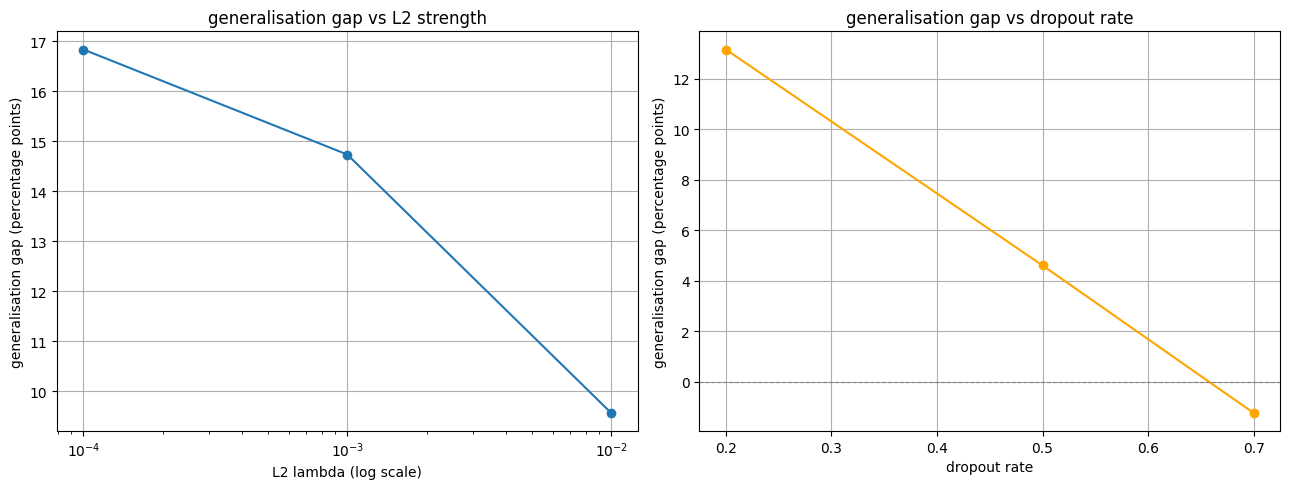

In [126]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

# L2 plot
l2_gaps = [l2_results[lam]['gap']*100 for lam in l2_lambdas]
axes[0].plot(l2_lambdas, l2_gaps, marker='o')
axes[0].set_xscale('log')
axes[0].set_xlabel('L2 lambda (log scale)')
axes[0].set_ylabel('generalisation gap (percentage points)')
axes[0].set_title('generalisation gap vs L2 strength')
axes[0].grid(True)

# Dropout plot
dropout_gaps = [dropout_results[r]['gap']*100 for r in dropout_rates]
axes[1].plot(dropout_rates, dropout_gaps, marker='o', color='orange')
axes[1].axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('dropout rate')
axes[1].set_ylabel('generalisation gap (percentage points)')
axes[1].set_title('generalisation gap vs dropout rate')
axes[1].grid(True)

plt.tight_layout()
plt.show()

Early stopping gave the best trade-off overall. It cut the gap from 17.23 to 6.26 points, a reduction of about 11 points, while training accuracy only dropped from 99.35% to 88.35% — and it did this in just 13 epochs instead of 60. Dropout at rate 0.5 achieved an even smaller final gap (4.60 points) with a similar accuracy cost, but required testing multiple rates to find that sweet spot, and going slightly further (0.7) caused underfitting. More training data (20,000 samples) improved both training and validation accuracy simultaneously, reaching the highest validation accuracy of all methods (87.63%), but only shrank the gap moderately, since it addresses data scarcity rather than model capacity directly. Overall, early stopping offered the best gap reduction relative to training accuracy lost, and was also the cheapest to run.

**Part -07**

In [127]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import KFold
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

random.seed(42)
np.random.seed(42)

# search space over 3 hyperparameters
search_space = {
    'learning_rate': [0.0001, 0.0005, 0.001, 0.005, 0.01],
    'hidden_width': [64, 128, 256, 512],
    'dropout_rate': [0.0, 0.2, 0.3, 0.5]
}

def sample_config():
    return {
        'learning_rate': random.choice(search_space['learning_rate']),
        'hidden_width': random.choice(search_space['hidden_width']),
        'dropout_rate': random.choice(search_space['dropout_rate'])
    }

# sample 12 unique configs
n_configs = 12
configs = []
seen = set()
while len(configs) < n_configs:
    cfg = sample_config()
    cfg_tuple = tuple(cfg.values())
    if cfg_tuple not in seen:
        seen.add(cfg_tuple)
        configs.append(cfg)

for i, cfg in enumerate(configs):
    print(f"config {i+1}: {cfg}")

config 1: {'learning_rate': 0.0001, 'hidden_width': 64, 'dropout_rate': 0.3}
config 2: {'learning_rate': 0.0005, 'hidden_width': 128, 'dropout_rate': 0.2}
config 3: {'learning_rate': 0.0001, 'hidden_width': 64, 'dropout_rate': 0.5}
config 4: {'learning_rate': 0.0001, 'hidden_width': 64, 'dropout_rate': 0.0}
config 5: {'learning_rate': 0.0005, 'hidden_width': 128, 'dropout_rate': 0.0}
config 6: {'learning_rate': 0.01, 'hidden_width': 128, 'dropout_rate': 0.5}
config 7: {'learning_rate': 0.0005, 'hidden_width': 512, 'dropout_rate': 0.3}
config 8: {'learning_rate': 0.0001, 'hidden_width': 128, 'dropout_rate': 0.5}
config 9: {'learning_rate': 0.001, 'hidden_width': 256, 'dropout_rate': 0.2}
config 10: {'learning_rate': 0.0005, 'hidden_width': 256, 'dropout_rate': 0.0}
config 11: {'learning_rate': 0.0001, 'hidden_width': 512, 'dropout_rate': 0.0}
config 12: {'learning_rate': 0.001, 'hidden_width': 256, 'dropout_rate': 0.3}


In [128]:
class TunableMLP(nn.Module):
    def __init__(self, hidden_width, dropout_rate):
        super().__init__()
        self.fc1 = nn.Linear(784, hidden_width)
        self.fc2 = nn.Linear(hidden_width, hidden_width)
        self.fc3 = nn.Linear(hidden_width, 10)
        self.dropout = nn.Dropout(dropout_rate) if dropout_rate > 0 else None

    def forward(self, x):
        x = F.relu(self.fc1(x))
        if self.dropout: x = self.dropout(x)
        x = F.relu(self.fc2(x))
        if self.dropout: x = self.dropout(x)
        x = self.fc3(x)
        return x

In [129]:
def cv_score_config(cfg, X, y, k=5, epochs=8, subset_size=8000, seed=42):
    # use a subset of the full training data to keep search time reasonable
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(X), size=min(subset_size, len(X)), replace=False)
    X_sub, y_sub = X[idx], y[idx]

    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    fold_accs = []

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_sub)):
        X_tr, X_va = X_sub[train_idx], X_sub[val_idx]
        y_tr, y_va = y_sub[train_idx], y_sub[val_idx]

        X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
        y_tr_t = torch.tensor(y_tr, dtype=torch.long)
        X_va_t = torch.tensor(X_va, dtype=torch.float32).to(device)
        y_va_t = torch.tensor(y_va, dtype=torch.long).to(device)

        loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=64, shuffle=True)

        torch.manual_seed(seed + fold_idx)
        model = TunableMLP(cfg['hidden_width'], cfg['dropout_rate']).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=cfg['learning_rate'])

        for epoch in range(epochs):
            model.train()
            for xb, yb in loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                logits = model(xb)
                loss = F.cross_entropy(logits, yb)
                loss.backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            preds = model(X_va_t).argmax(dim=1)
            acc = (preds == y_va_t).float().mean().item()
        fold_accs.append(acc)

    return np.mean(fold_accs), np.std(fold_accs)

In [130]:
results = []

for i, cfg in enumerate(configs):
    print(f"\n--- config {i+1}/12: {cfg} ---")
    mean_acc, std_acc = cv_score_config(cfg, X_train, y_train)
    results.append({'config': cfg, 'mean_acc': mean_acc, 'std_acc': std_acc})
    print(f"mean cv accuracy: {mean_acc:.4f}, std: {std_acc:.4f}")


--- config 1/12: {'learning_rate': 0.0001, 'hidden_width': 64, 'dropout_rate': 0.3} ---
mean cv accuracy: 0.7007, std: 0.0133

--- config 2/12: {'learning_rate': 0.0005, 'hidden_width': 128, 'dropout_rate': 0.2} ---
mean cv accuracy: 0.8346, std: 0.0078

--- config 3/12: {'learning_rate': 0.0001, 'hidden_width': 64, 'dropout_rate': 0.5} ---
mean cv accuracy: 0.6661, std: 0.0143

--- config 4/12: {'learning_rate': 0.0001, 'hidden_width': 64, 'dropout_rate': 0.0} ---
mean cv accuracy: 0.7536, std: 0.0099

--- config 5/12: {'learning_rate': 0.0005, 'hidden_width': 128, 'dropout_rate': 0.0} ---
mean cv accuracy: 0.8349, std: 0.0089

--- config 6/12: {'learning_rate': 0.01, 'hidden_width': 128, 'dropout_rate': 0.5} ---
mean cv accuracy: 0.7662, std: 0.0057

--- config 7/12: {'learning_rate': 0.0005, 'hidden_width': 512, 'dropout_rate': 0.3} ---
mean cv accuracy: 0.8409, std: 0.0101

--- config 8/12: {'learning_rate': 0.0001, 'hidden_width': 128, 'dropout_rate': 0.5} ---
mean cv accuracy: 0

In [131]:
sorted_results = sorted(results, key=lambda r: r['mean_acc'], reverse=True)

print("=== Top 5 configurations by mean CV accuracy ===\n")
for i, r in enumerate(sorted_results[:5]):
    print(f"{i+1}. config: {r['config']}")
    print(f"   mean cv accuracy: {r['mean_acc']:.4f}, std: {r['std_acc']:.4f}\n")

selected_config = sorted_results[0]['config']
print(f"selected configuration: {selected_config}")

=== Top 5 configurations by mean CV accuracy ===

1. config: {'learning_rate': 0.001, 'hidden_width': 256, 'dropout_rate': 0.2}
   mean cv accuracy: 0.8462, std: 0.0105

2. config: {'learning_rate': 0.001, 'hidden_width': 256, 'dropout_rate': 0.3}
   mean cv accuracy: 0.8456, std: 0.0094

3. config: {'learning_rate': 0.0005, 'hidden_width': 512, 'dropout_rate': 0.3}
   mean cv accuracy: 0.8409, std: 0.0101

4. config: {'learning_rate': 0.0005, 'hidden_width': 256, 'dropout_rate': 0.0}
   mean cv accuracy: 0.8404, std: 0.0099

5. config: {'learning_rate': 0.0005, 'hidden_width': 128, 'dropout_rate': 0.0}
   mean cv accuracy: 0.8349, std: 0.0089

selected configuration: {'learning_rate': 0.001, 'hidden_width': 256, 'dropout_rate': 0.2}


In [132]:
def train_final_model(cfg, X, y, X_val, y_val, epochs=60, patience=5, seed=42):
    torch.manual_seed(seed)

    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)

    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=128, shuffle=True)

    model = TunableMLP(cfg['hidden_width'], cfg['dropout_rate']).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['learning_rate'])

    best_val_loss = float('inf')
    patience_counter = 0
    stopped_epoch = epochs

    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t)
            val_loss = F.cross_entropy(val_logits, y_val_t).item()
            val_acc = (val_logits.argmax(1) == y_val_t).float().mean().item()

        print(f"epoch {epoch}/{epochs} - val loss: {val_loss:.4f} - val acc: {val_acc:.4f}")

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                stopped_epoch = epoch
                print(f"\nearly stopping triggered at epoch {epoch}")
                break

    return model, stopped_epoch

final_model, final_stopped_epoch = train_final_model(selected_config, X_train, y_train, X_val, y_val)

epoch 1/60 - val loss: 0.4320 - val acc: 0.8403
epoch 2/60 - val loss: 0.3988 - val acc: 0.8536
epoch 3/60 - val loss: 0.3576 - val acc: 0.8668
epoch 4/60 - val loss: 0.3361 - val acc: 0.8761
epoch 5/60 - val loss: 0.3306 - val acc: 0.8770
epoch 6/60 - val loss: 0.3221 - val acc: 0.8799
epoch 7/60 - val loss: 0.3119 - val acc: 0.8835
epoch 8/60 - val loss: 0.3170 - val acc: 0.8838
epoch 9/60 - val loss: 0.3125 - val acc: 0.8866
epoch 10/60 - val loss: 0.3186 - val acc: 0.8848
epoch 11/60 - val loss: 0.3155 - val acc: 0.8817
epoch 12/60 - val loss: 0.3254 - val acc: 0.8817

early stopping triggered at epoch 12


test accuracy: 88.16%
macro precision: 0.8826
macro recall: 0.8816
macro f1: 0.8806


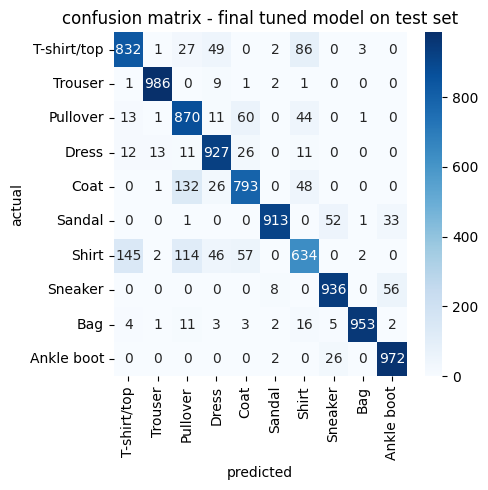

In [133]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)

final_model.eval()
with torch.no_grad():
    test_logits = final_model(X_test_t)
    test_preds = test_logits.argmax(dim=1).cpu().numpy()

y_test_np = y_test  

test_acc = accuracy_score(y_test_np, test_preds)
macro_precision = precision_score(y_test_np, test_preds, average='macro')
macro_recall = recall_score(y_test_np, test_preds, average='macro')
macro_f1 = f1_score(y_test_np, test_preds, average='macro')

print(f"test accuracy: {test_acc*100:.2f}%")
print(f"macro precision: {macro_precision:.4f}")
print(f"macro recall: {macro_recall:.4f}")
print(f"macro f1: {macro_f1:.4f}")

# confusion matrix
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

cm = confusion_matrix(y_test_np, test_preds)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('confusion matrix - final tuned model on test set')
plt.tight_layout()
plt.show()

The tuned model reached 88.16% test accuracy, compared to 83.35% for the Part 2 baseline — an improvement of 4.81 percentage points. This is a real improvement, not a lucky number: it comes from a wider hidden layer (256 units instead of 128), a learning rate chosen through cross-validation instead of a guess, and early stopping to avoid the overfitting we saw happen in Part 5. Looking at the confusion matrix, most of the remaining mistakes are between T-shirts, pullovers, coats, and shirts — these classes just look alike in the images, so this is expected and not a sign that the model is doing something wrong.